In [1]:
# Basic imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
DATA_PATH = "daily_water_consumption.csv"
try:
    df = pd.read_csv(DATA_PATH)
except Exception as e:
    print(f"Could not read {DATA_PATH}: {e}\nPlease upload your CSV to the Colab session and update DATA_PATH.")
    raise

print("Dataset shape:", df.shape)
display(df.head())
display(df.describe(include='all').T)


Dataset shape: (36500, 8)


,Date,Person_ID,Age,Gender,City,Temperature_C,Activity_Level,Water_Consumed_Liters
0,2025-01-01,P0001,21,Female,Karachi,22.1,Medium,2.40
1,2025-01-02,P0001,21,Female,Karachi,41.0,Medium,3.31
2,2025-01-03,P0001,21,Female,Karachi,26.4,High,2.96
3,2025-01-04,P0001,21,Female,Karachi,31.4,Medium,3.16
4,2025-01-05,P0001,21,Female,Karachi,35.7,Low,2.43


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,36500,365,2025-12-31,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Person_ID,36500,100,P0001,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,36500.0,NaN,NaN,NaN,40.43,13.365253,18.0,29.75,40.5,52.0,64.0
Gender,36500,3,Male,18615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,36500,6,Rawalpindi,11315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Temperature_C,36500.0,NaN,NaN,NaN,28.538447,7.789702,15.0,21.8,28.6,35.3,42.0
Activity_Level,36500,3,Medium,18216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Water_Consumed_Liters,36500.0,NaN,NaN,NaN,2.724002,0.550482,1.3,2.35,2.72,3.13,4.17


In [3]:
missing = df.isnull().sum()
display(missing[missing>0])

if missing.sum() > 0:
    df = df.fillna(df.mean(numeric_only=True))
    df = df.fillna(df.mode().iloc[0])
    print("Filled missing values using mean (numeric) and mode (categorical).")
else:
    print("No missing values found.")


Series([], dtype: int64)

No missing values found.


In [4]:
# Feature Selection
df.drop(['Date', 'Person_ID', 'City'], axis=1, inplace=True)
df

,Age,Gender,Temperature_C,Activity_Level,Water_Consumed_Liters
0,21,Female,22.1,Medium,2.40
1,21,Female,41.0,Medium,3.31
2,21,Female,26.4,High,2.96
3,21,Female,31.4,Medium,3.16
4,21,Female,35.7,Low,2.43
...,...,...,...,...,...
36495,55,Male,22.7,Medium,2.49
36496,55,Male,39.3,High,3.54
36497,55,Male,40.6,Low,2.93
36498,55,Male,34.1,Low,2.23


In [5]:
#define target variable
target = 'Water_Consumed_Liters'

#identify numeric and categorical columns first
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# remove target from numeric_cols if present
if target in numeric_cols:
    numeric_cols.remove(target)


print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nTarget variable: {target}")

Numeric columns (2): ['Age', 'Temperature_C']

Categorical columns (2): ['Gender', 'Activity_Level']

Target variable: Water_Consumed_Liters


In [6]:
# Separate features and target
X = df.drop(columns=[target]).copy()
y = df[target].copy()


In [7]:
#now we use OneHotEncoder with drop='first' to avoid multicollinearity
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

#we'll pass numeric columns through unchanged (to keep units), but we will still ensure numeric dtype
def identity_transform(X):
    return X

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_cols)
], remainder='passthrough')  # passthrough leaves numeric columns as-is

#now we check of the preprocessor output feature names after fitting (we'll fit later) using scikit-learn
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Gender', 'Activity_Level'])])

In [8]:
# First split: Train (80%) and Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Second split: from X_temp (80%) produce Train (80% of 80%) and Val (20% of 80%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.20, random_state=42)

print(f"Final splits -> Train: {len(X_train)} rows, Validation: {len(X_val)} rows, Test: {len(X_test)} rows")


Final splits -> Train: 23360 rows, Validation: 5840 rows, Test: 7300 rows


In [9]:

# preprocessor -> LinearRegression (OLS) Initialisation
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('ols', LinearRegression())])

# Fit pipeline on training data -> Training
model_pipeline.fit(X_train, y_train)



c:\Users\EL-YaMaMa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender',
                                                   'Activity_Level'])])),
                ('ols', LinearRegression())])

In [10]:
# Predictions
y_train_pred = model_pipeline.predict(X_train)
y_val_pred = model_pipeline.predict(X_val)

In [11]:
# Compute losses (MSE) and other metrics
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)

train_rmse = np.sqrt(train_mse)
val_rmse = np.sqrt(val_mse)

print(f'Train MSE: {train_mse:.4f}, Train RMSE: {train_rmse:.4f}')
print(f'Val   MSE: {val_mse:.4f}, Val   RMSE: {val_rmse:.4f}')



Train MSE: 0.0209, Train RMSE: 0.1444
Val   MSE: 0.0209, Val   RMSE: 0.1445


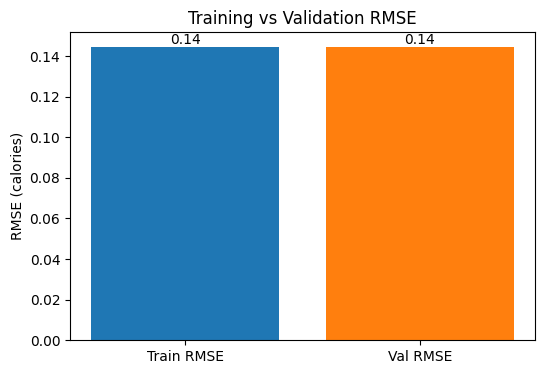

In [12]:
plt.figure(figsize=(6,4))
plt.bar(['Train RMSE', 'Val RMSE'], [train_rmse, val_rmse], color=['tab:blue','tab:orange'])
plt.ylabel('RMSE (calories)')
plt.title('Training vs Validation RMSE')
for i, v in enumerate([train_rmse, val_rmse]):
    plt.text(i, v + max(train_rmse, val_rmse)*0.01, f'{v:.2f}', ha='center')
plt.show()


In [13]:
ols = model_pipeline.named_steps['ols']
ohe = model_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = []
if hasattr(ohe, 'get_feature_names_out'):
    cat_feature_names = list(ohe.get_feature_names_out(categorical_cols))
else:
    cat_feature_names = ohe.get_feature_names(categorical_cols).tolist()

feature_names = cat_feature_names + numeric_cols

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient Estimate': ols.coef_
}).reset_index(drop=True)

display(coef_df)


,Feature,Coefficient Estimate
0,Gender_Male,0.004515
1,Gender_Other,0.007751
2,Activity_Level_Low,-0.996455
3,Activity_Level_Medium,-0.395380
4,Age,-0.002129
5,Temperature_C,0.049876


In [14]:
y_test_pred = model_pipeline.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R² : {test_r2:.4f}")

Test MSE: 0.0212
Test RMSE: 0.1455
Test MAE: 0.1262
Test R² : 0.9313


In [15]:
OUT_PATH = "model_pipeline_ols.pkl"
joblib.dump(model_pipeline, OUT_PATH)
print(f"Saved model pipeline to: {OUT_PATH}")


#Saved model pipeline to: model_pipeline_ols.pkl

Saved model pipeline to: model_pipeline_ols.pkl
